In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from DNAnet.models.segmentation.threshold import ThresholdSegmentationModel
from DNAnet.data.data_models.custom_hid_dataset import CustomHIDDataset
from DNAnet.data.parsing.file_categorization_strategy import ProvedItFileCategorizer
from DNAnet.data.validation.sample_validation_strategy import NFIValidationStrategy
from DNAnet.data.kit_compatibility.lane_standards import InternalSizeStandard

from DNAnet.evaluation.visualizations import plot_profile


# Test Baseline Threshold Segmentation Model

This notebook demonstrates how to load a HID dataset, apply the baseline threshold segmentation model, and inspect predictions.

In [3]:
# Create HID Dataset
gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles"
reference_genotype_path = "/Users/amarmesic/Documents/tudelft/thesis/DNANet/resources/data/ProvedIt/References"
file_categorizer = ProvedItFileCategorizer()
sample_validator = NFIValidationStrategy()
dataset = CustomHIDDataset(
    root_path=hid_files_path,
    panel_path=gf_panel_path,
    size_standard=InternalSizeStandard.GENESCAN_600_LIZ.value,
    file_categorization_strategy=file_categorizer,
    sample_validation_strategy=sample_validator,
)

2025-08-12 23:12:12 INFO     Found 675 files in /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles
2025-08-12 23:12:13 WARNING  Size standard for E04_RD14-0003-33_34-1,2-M4d-0.045GF-Q1.3_05.5sec.hid differs 18.912544484957948 from the expected 
2025-08-12 23:12:13 WARNING  Size standard for E04_RD14-0003-33_34-1,2-M4d-0.045GF-Q1.3_05.5sec.hid differs 18.912544484957948 from the expected 
2025-08-12 23:12:16 WARNING  Size standard for H08_RD14-0003-49_50_29-1,4,1-M2e-0.378GF-Q1.4_08.5sec.hid differs 13.401428160223645 from the expected 
2025-08-12 23:12:16 WARNING  Size standard for H08_RD14-0003-49_50_29-1,4,1-M2e-0.378GF-Q1.4_08.5sec.hid differs 13.401428160223645 from the expected 
2025-08-12 23:12:18 WARNING  Size standard for G03_RD14-0003-40_41-1,4-M3e-0.625GF-Q0.8_07.5sec.hid differs 12.982847650856456 from the expected 
2025-08-12 23:12:18 WARNING  Size standard for G03_RD14-0003-40_41-1,4-M3e-0.625GF-Q0.8_07.5sec.hid 

In [24]:
# Initialize the baseline thresholding model
model = ThresholdSegmentationModel(threshold=70, apply_allele_caller=True)

# make a list of predictions
predictions = [model.predict(image) for image in dataset]

# Print shapes of the dataset and predictions
dataset[0].data.shape, predictions[0].image.shape

2025-08-12 23:20:20 WARNING  No predictions present in dye row 0
2025-08-12 23:20:21 WARNING  No predictions present in dye row 2
2025-08-12 23:20:21 WARNING  No predictions present in dye row 3
2025-08-12 23:20:21 WARNING  No predictions present in dye row 2
2025-08-12 23:20:21 WARNING  No predictions present in dye row 3


((5, 4096, 1), (5, 4096, 1))

In [25]:
from DNAnet.evaluation.segmentation.allele_metrics import allele_f1_score, allele_precision, allele_recall
from DNAnet.evaluation.segmentation.pixel_metrics import pixel_f1_score, pixel_precision, pixel_recall

f1 = pixel_f1_score(dataset, predictions)
precision = pixel_precision(dataset, predictions)
recall = pixel_recall(dataset, predictions)
print(f"- Pixel F1 Score: {f1:.4g}")
print(f"- Pixel Precision: {precision:.4g}")
print(f"- Pixel Recall: {recall:.4g}")

alelle_f1 = allele_f1_score(dataset, predictions)
print(f'- Allele F1 Score: {alelle_f1:.4g}')
print(f'- Allele Precision: {allele_precision(dataset, predictions):.4g}')
print(f'- Allele Recall: {allele_recall(dataset, predictions):.4g}')

- Pixel F1 Score: 0.5741
- Pixel Precision: 0.5376
- Pixel Recall: 0.6159
- Allele F1 Score: 0.771
- Allele F1 Score: 0.771
- Allele Precision: 0.7618
- Allele Precision: 0.7618
- Allele Recall: 0.7805
- Allele Recall: 0.7805


## Tracking Performance of different thresholds

### 70 - Best Pixel F1
- Pixel F1 Score: 0.5741
- Pixel Precision: 0.5376
- Pixel Recall: 0.6159
- Allele F1 Score: 0.771
- Allele Precision: 0.7618
- Allele Recall: 0.7805

### 75 - Best Allele F1
- Pixel F1 Score: 0.5735
- Pixel Precision: 0.5425
- Pixel Recall: 0.6082
- Allele F1 Score: 0.7738
- Allele Precision: 0.7726
- Allele Recall: 0.7749

### 100
- Pixel F1 Score: 0.561
- Pixel Precision: 0.5737
- Pixel Recall: 0.5488
- Allele F1 Score: 0.7699
- Allele Precision: 0.8186
- Allele Recall: 0.7267

## Visualize Example Prediction

Let's visualize the segmentation mask for the first image in the dataset.

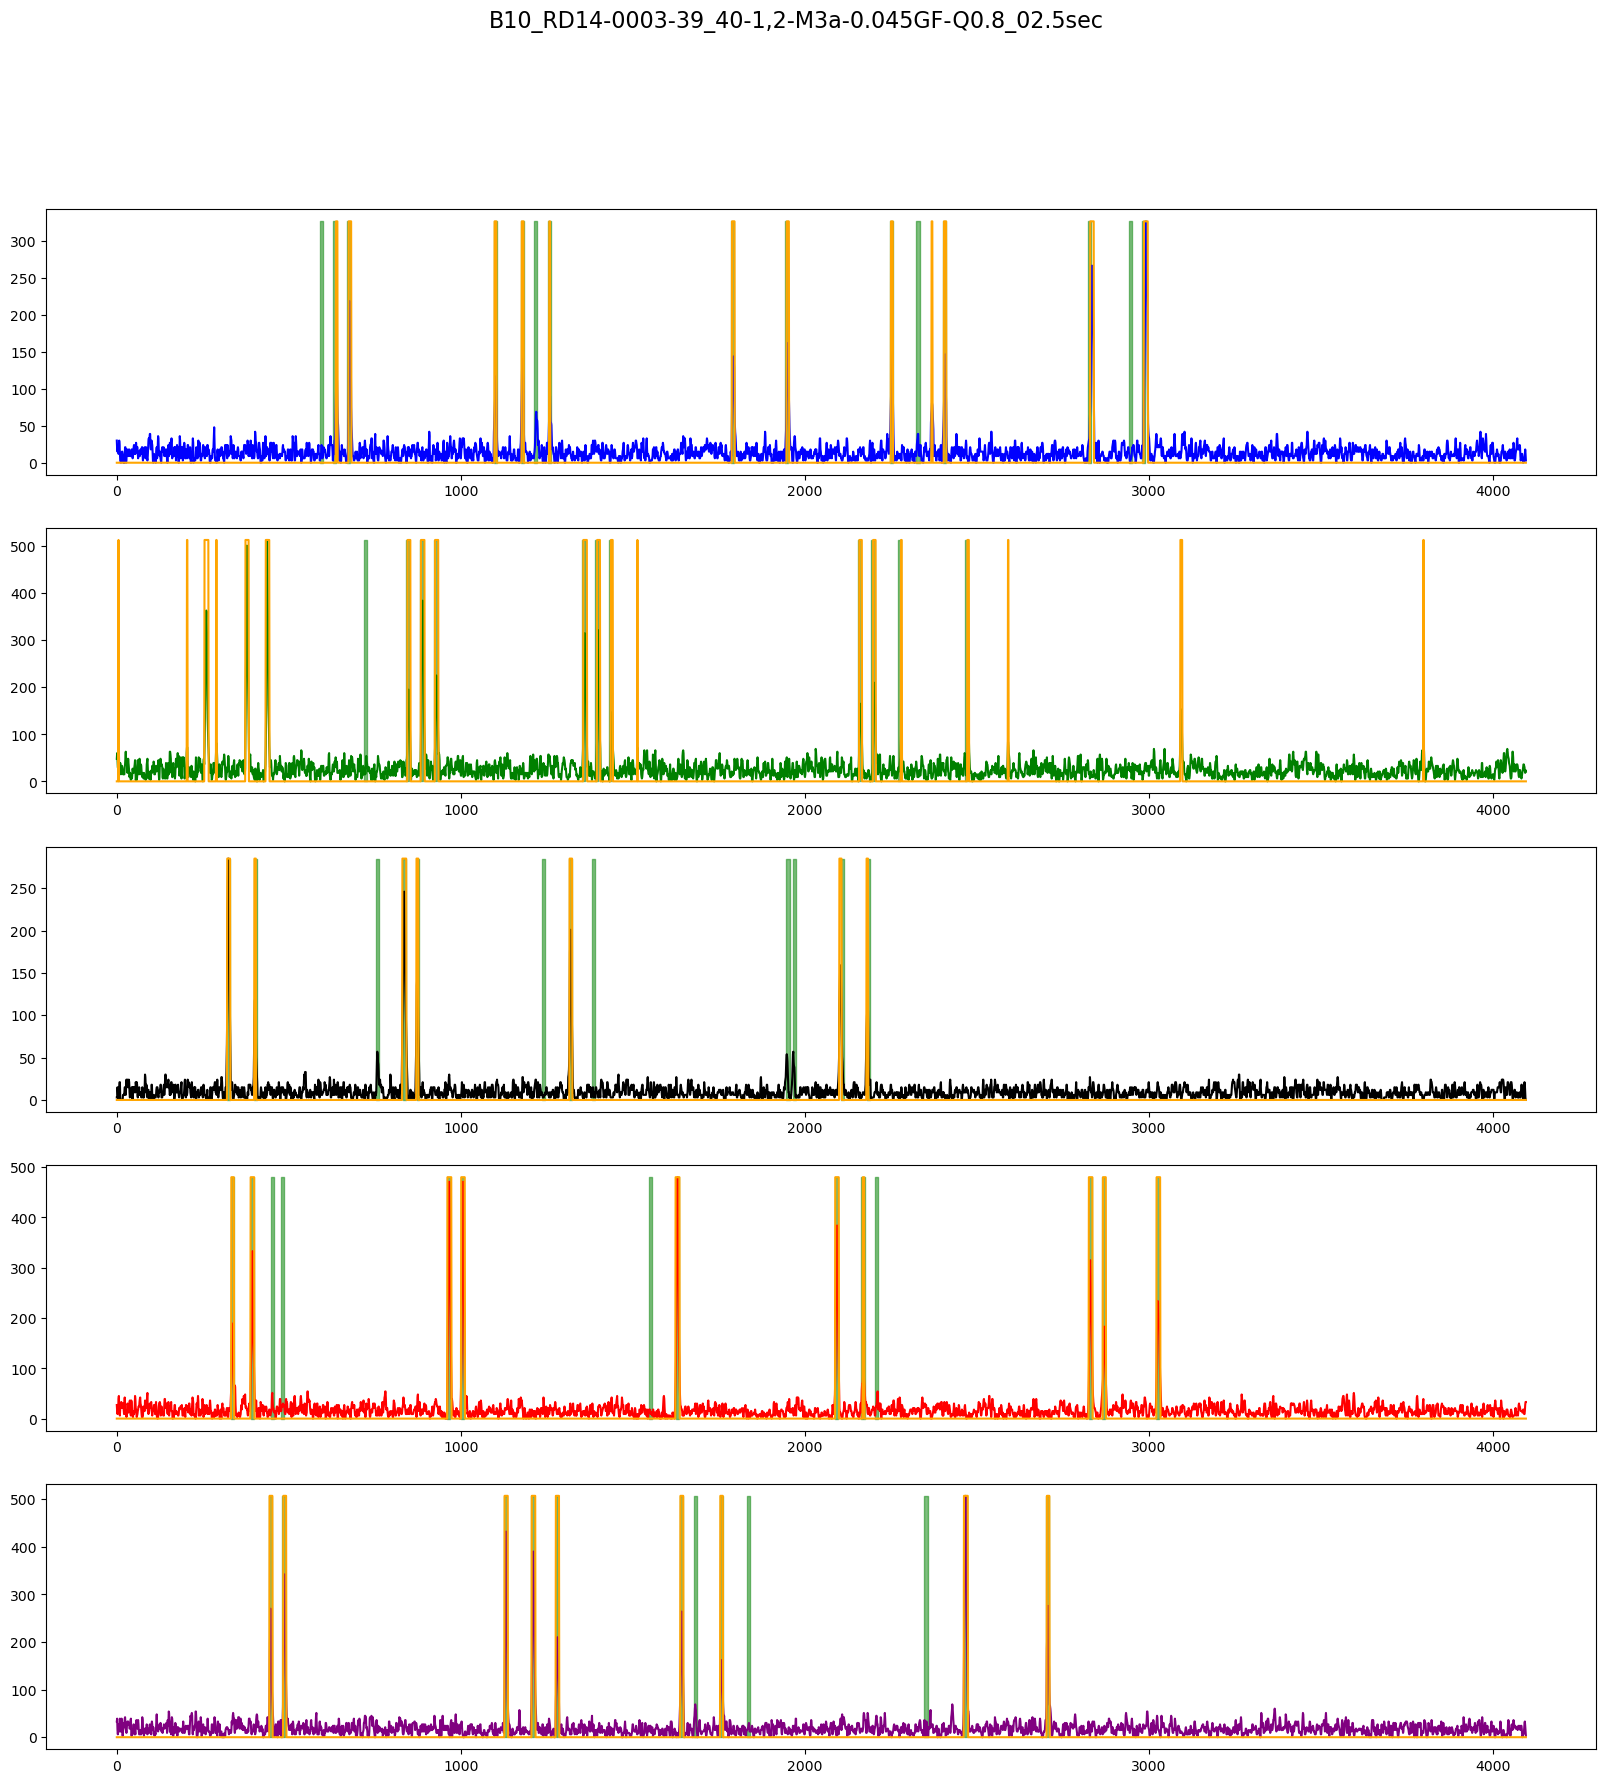

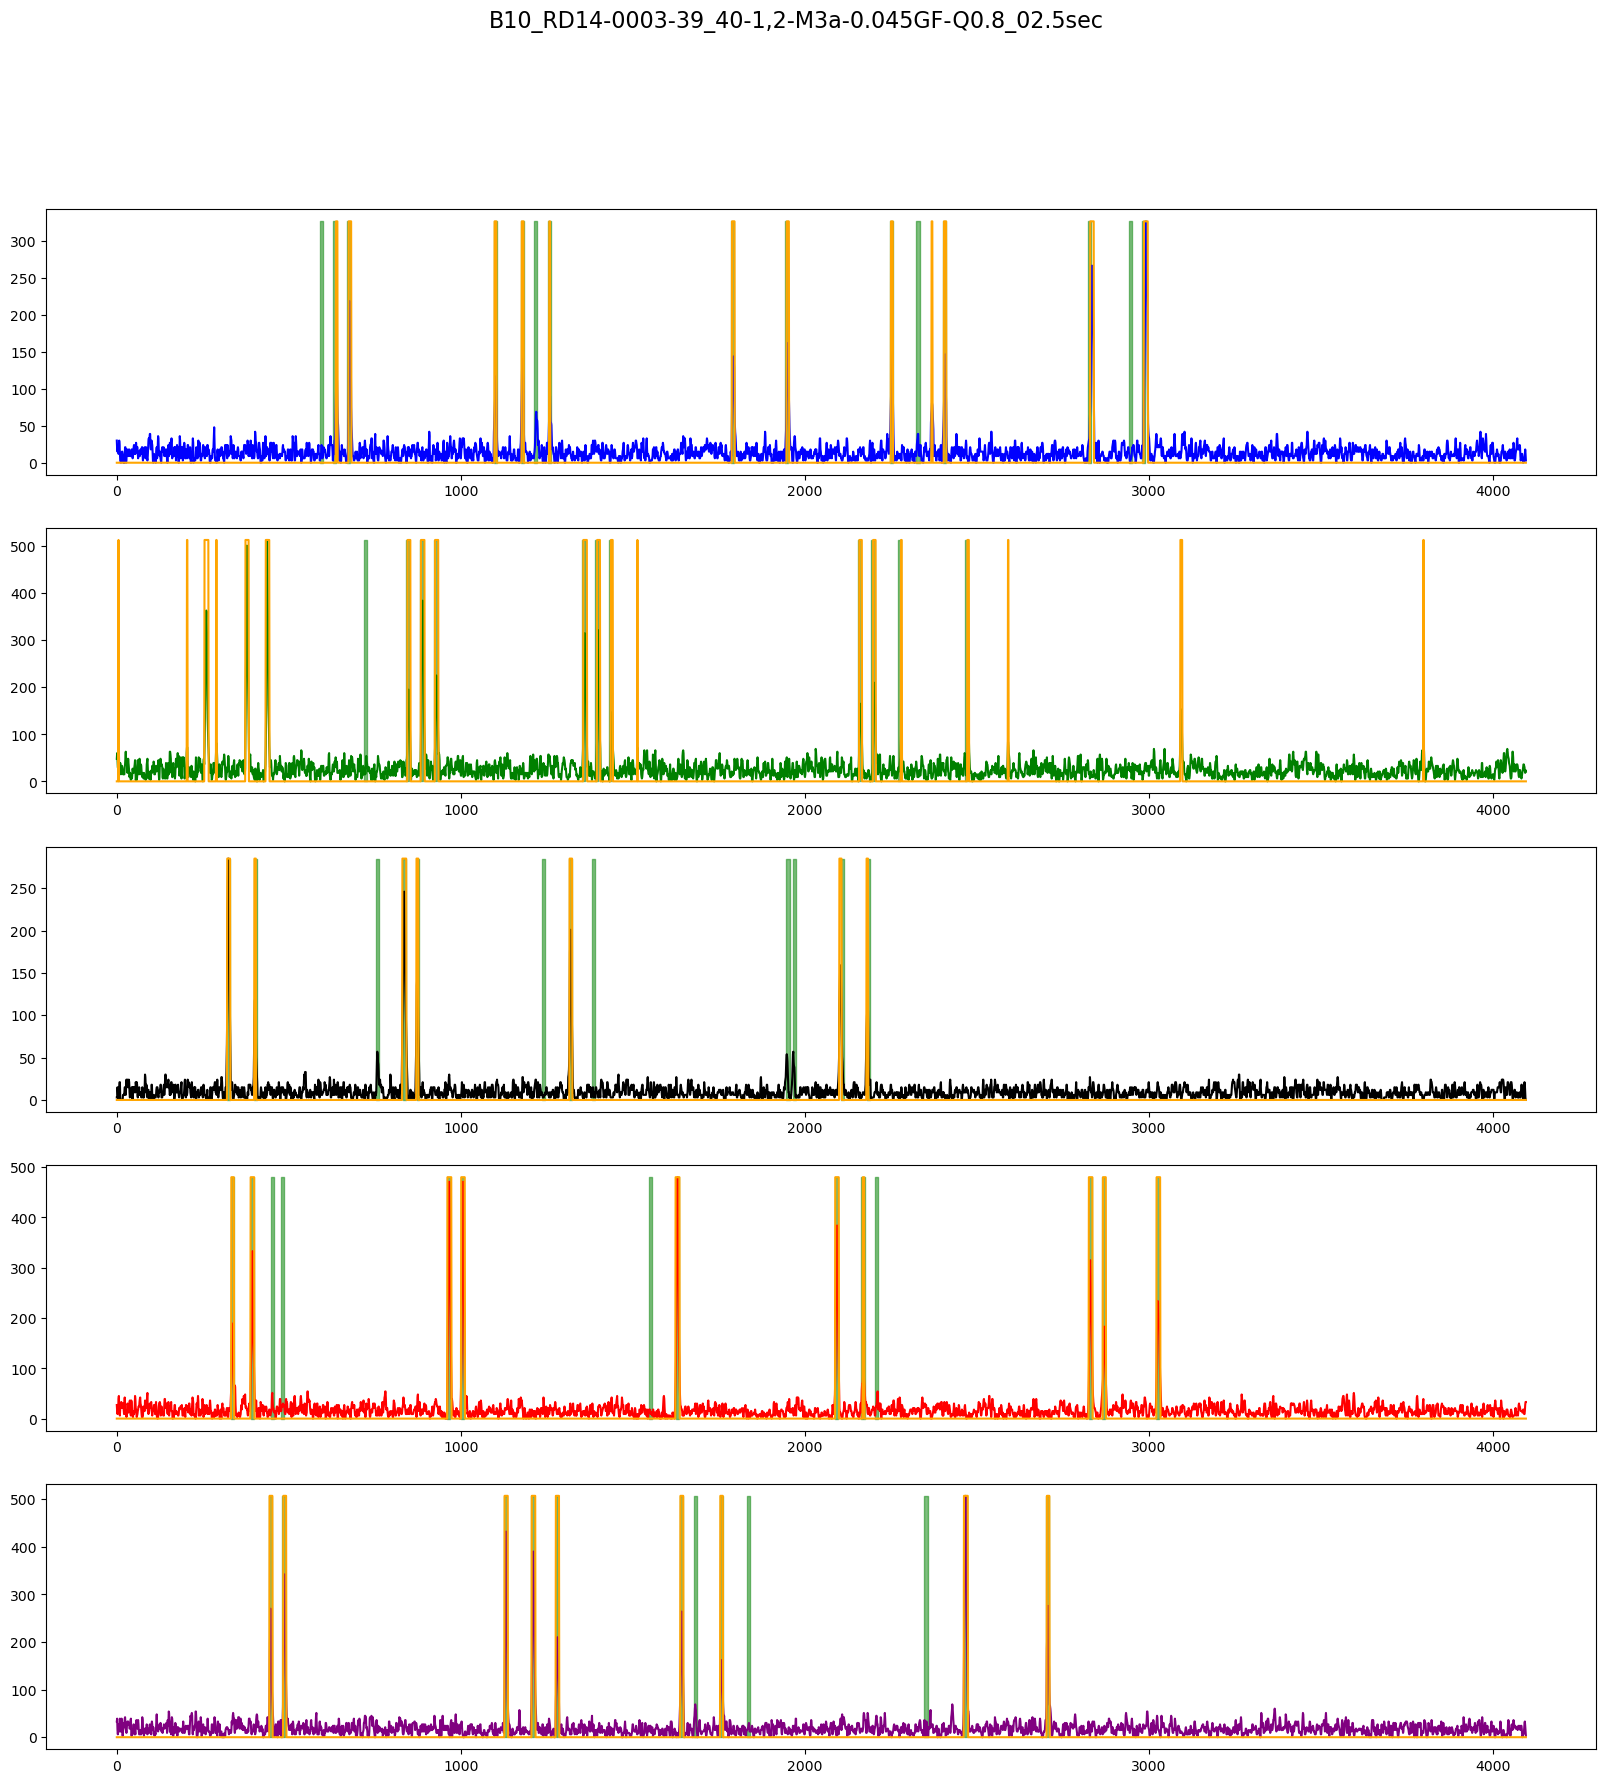

In [26]:
plot_profile(dataset[:1], predictions[:1], prediction_as_mask=False)

In [27]:
import neptune
run = neptune.init_run(
    name="dummy-baseline-70",
    project="amar-mesic/dna-thesis",
    api_token="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiJkOTQ1Njc4MC0yOTcyLTRlMmQtYTMwMy0xOGYxZTAwMmIzZGUifQ==",
)

run["metrics/pixel_f1"] = float(f"{f1:.4g}")
run["metrics/pixel_precision"] = float(f"{precision:.4g}")
run["metrics/pixel_recall"] = float(f"{recall:.4g}")
run["metrics/allele_f1"] = float(f"{alelle_f1:.4g}")
run["metrics/allele_precision"] = float(f"{allele_precision(dataset, predictions):.4g}")
run["metrics/allele_recall"] = float(f"{allele_recall(dataset, predictions):.4g}")
run.stop()

[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs-legacy.neptune.ai/logging/source_code/


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/amar-mesic/dna-thesis/e/DNAT-159
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 6 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 6 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 6 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/amar-mesic/dna-thesis/e/DNAT-159/metadata
[neptune] [info   ] All 6 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/amar-mesic/dna-thesis/e/DNAT-159/metadata
